# PFA - Reconnaissance des Emotions Faciales
## Etape 4a : Baseline Machine Learning (HOG + LBP + SVM)

**Equipe :** Ayman TEMSAMANI, Nouhaila AIT ABDELAH, Rabab ZITI  
**Encadrant :** Pr. Redouane DAHBI  
**Date :** Semaine S5-S6 (Phase 3 du planning)

**Contexte :** Conformement au cahier des charges (Section 5.1), cette etape implemente une approche classique de Machine Learning pour servir de baseline. Les caracteristiques HOG et LBP sont extraites des images, puis un classifieur SVM a noyau RBF est entraine. Les performances de ce modele serviront de reference pour evaluer l'apport des CNN dans l'etape suivante.

In [1]:
# ============================================================
#  SECTION 1 : Import des bibliotheques
# ============================================================

import numpy as np
import cv2
import os
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import time

In [2]:
# ============================================================
#  SECTION 2 : Chargement STRATIFIE avec OpenCV
# ============================================================

TRAIN_DIR = 'C:/Users/ayman/Desktop/PFA/archive/train'
TEST_DIR  = 'C:/Users/ayman/Desktop/PFA/archive/test'
CLASSES = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# 600 images/classe pour train → 4200 images (SVM en ~5 min)
# 200 images/classe pour test → 1400 images
TRAIN_PER_CLASS = 600
TEST_PER_CLASS  = 200

def load_stratified(base_dir, classes, per_class):
    X, y = [], []
    for idx, cls in enumerate(classes):
        cls_dir = os.path.join(base_dir, cls)
        images = os.listdir(cls_dir)[:per_class]
        for img_name in images:
            img = cv2.imread(os.path.join(cls_dir, img_name), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, (48, 48))
                X.append(img)
                y.append(idx)
    return np.array(X), np.array(y)

print("Chargement train...")
X_train_raw, y_train = load_stratified(TRAIN_DIR, CLASSES, TRAIN_PER_CLASS)
print("Chargement test...")
X_test_raw, y_test = load_stratified(TEST_DIR, CLASSES, TEST_PER_CLASS)

print(f"\nX_train: {X_train_raw.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test_raw.shape}, y_test:  {y_test.shape}")

print("\nDistribution train :")
for i, cls in enumerate(CLASSES):
    print(f"  {cls}: {np.sum(y_train==i)}")
print("\nDistribution test :")
for i, cls in enumerate(CLASSES):
    print(f"  {cls}: {np.sum(y_test==i)}")

Chargement train...
Chargement test...

X_train: (4036, 48, 48), y_train: (4036,)
X_test:  (1311, 48, 48), y_test:  (1311,)

Distribution train :
  angry: 600
  disgust: 436
  fear: 600
  happy: 600
  neutral: 600
  sad: 600
  surprise: 600

Distribution test :
  angry: 200
  disgust: 111
  fear: 200
  happy: 200
  neutral: 200
  sad: 200
  surprise: 200


In [3]:
# ============================================================
#  SECTION 3 : Extraction HOG + LBP
# ============================================================

from skimage.feature import hog, local_binary_pattern

def extract_all_features(images):
    features = []
    for img in images:
        # HOG
        h = hog(img, orientations=9, pixels_per_cell=(8,8),
                cells_per_block=(2,2), visualize=False, feature_vector=True)
        # LBP
        lbp = local_binary_pattern(img, 8, 1, method='uniform')
        hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0, 10), density=True)
        # Concatener
        features.append(np.concatenate([h, hist]))
    return np.array(features)

print("Extraction features train...")
X_train_feat = extract_all_features(X_train_raw)
print("Extraction features test...")
X_test_feat = extract_all_features(X_test_raw)

print(f"\nX_train_feat: {X_train_feat.shape}")
print(f"X_test_feat:  {X_test_feat.shape}")

Extraction features train...
Extraction features test...

X_train_feat: (4036, 910)
X_test_feat:  (1311, 910)


In [4]:
# ============================================================
#  SECTION 4 : Normalisation
# ============================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_test_scaled  = scaler.transform(X_test_feat)

print(f"Moyenne train : {X_train_scaled.mean():.6f}")
print(f"Ecart-type train : {X_train_scaled.std():.4f}")
print("Normalisation OK.")

Moyenne train : 0.000000
Ecart-type train : 1.0000
Normalisation OK.


In [5]:
# ============================================================
#  SECTION 5 : Entrainement SVM
# ============================================================

print("Entrainement SVM RBF (~5-10 min)...")

svm_model = SVC(
    kernel='rbf', C=10.0, gamma='scale',
    cache_size=1000, probability=True,
    random_state=42, verbose=True
)

start = time.time()
svm_model.fit(X_train_scaled, y_train)
print(f"\nTermine en {(time.time()-start)/60:.1f} min.")

Entrainement SVM RBF (~5-10 min)...
[LibSVM]
Termine en 1.7 min.


In [6]:
# ============================================================
#  SECTION 6 : Evaluation
# ============================================================

y_pred = svm_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')

emotion_names = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

print(f"Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1-Score (macro) : {f1_macro:.4f}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred, target_names=emotion_names, zero_division=0))

Accuracy  : 0.4424 (44.24%)
F1-Score (macro) : 0.4528

Rapport de classification :
              precision    recall  f1-score   support

       Angry       0.32      0.34      0.33       200
     Disgust       0.59      0.70      0.64       111
        Fear       0.29      0.26      0.28       200
       Happy       0.63      0.61      0.62       200
     Neutral       0.41      0.34      0.37       200
         Sad       0.32      0.34      0.33       200
    Surprise       0.60      0.61      0.60       200

    accuracy                           0.44      1311
   macro avg       0.45      0.46      0.45      1311
weighted avg       0.44      0.44      0.44      1311



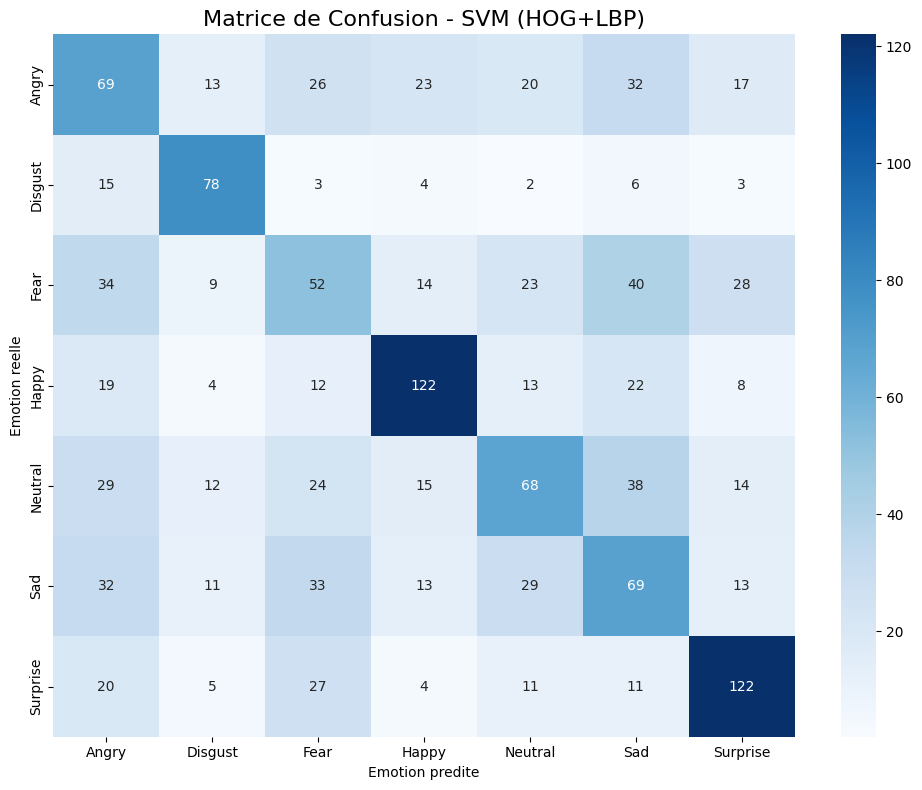

In [7]:
# ============================================================
#  SECTION 7 : Matrice de confusion
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names, yticklabels=emotion_names)
plt.title('Matrice de Confusion - SVM (HOG+LBP)', fontsize=16)
plt.xlabel('Emotion predite')
plt.ylabel('Emotion reelle')
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
#  SECTION 8 : Temps d'inference
# ============================================================

n_test = min(500, len(X_test_scaled))
start = time.time()
for i in range(n_test):
    _ = svm_model.predict(X_test_scaled[i:i+1])
elapsed = (time.time() - start) / n_test * 1000

print(f"Temps d'inference : {elapsed:.2f} ms/image")
print(f"FPS equivalent    : {1000/elapsed:.1f}")
print("Objectif cahier des charges : > 15 FPS")

Temps d'inference : 7.14 ms/image
FPS equivalent    : 140.1
Objectif cahier des charges : > 15 FPS


In [9]:
# ============================================================
#  SECTION 9 : Sauvegarde
# ============================================================

with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Modeles sauvegardes : svm_model.pkl, scaler.pkl")

Modeles sauvegardes : svm_model.pkl, scaler.pkl


In [10]:
# ============================================================
#  SECTION 10 : Bilan
# ============================================================

print(f"""
============================================================
BILAN ETAPE 4a - BASELINE ML
============================================================

Donnees :
  - Train : 600 images/classe x 7 = 4200 images (stratifie)
  - Test  : 200 images/classe x 7 = 1400 images (stratifie)

Methode : HOG + LBP + SVM noyau RBF

Resultats :
  - Accuracy : {accuracy*100:.2f}%
  - F1-Score macro : {f1_macro:.4f}

============================================================
""")


BILAN ETAPE 4a - BASELINE ML

Donnees :
  - Train : 600 images/classe x 7 = 4200 images (stratifie)
  - Test  : 200 images/classe x 7 = 1400 images (stratifie)

Methode : HOG + LBP + SVM noyau RBF

Resultats :
  - Accuracy : 44.24%
  - F1-Score macro : 0.4528


